# Cohort 03 Behavior Analysis

Select problems with `problem_numbers` (`None` means all available problems). Task names containing `mag` or `pretraining` are excluded.

- **Problems 1–3:** original choice-probability, first-leave, reversal-count, true-value rank-proportion, and single-session analyses.
- **Problem 4 onward:** reversal-count, true- and believed-value rank-proportion, and single-session analyses; choice-probability and first-leave analyses are disabled.

Both settings save separate rank-proportion plots with pooling within each mouse enabled and disabled. Filenames include the value basis and `Pool Trials True` or `Pool Trials False`; statistics are recomputed for each mode. Believed ranks use previously observed arm values before each choice, carry across sessions within a problem, exclude choices of unseen arms, and split ties evenly.


In [72]:
import importlib
import sys
from pathlib import Path
from unittest.mock import patch

repo_root = Path.cwd()
if not (repo_root / "src").is_dir():
    repo_root = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(repo_root))

import_data_module = importlib.import_module("src.behavior_import.import_data")

task = "open-field"
cohort_id = 3
cohort = "cohort-0{cohort_id}".format(cohort_id=cohort_id)
folder_name = "3x3_field_magnitude_bandit"
root = f"/Volumes/behrens/meg/{folder_name}/rawdata/{cohort}/"
excluded_task_name_parts = ("mag", "pretraining")
problem_numbers = {1, 2, 3, 4} # None = all available problems; e.g. {1, 4} or {4}.

# Original analyses for problems 1, 2, and 3.
original_analysis_settings = dict(
    run_choice_probability_analysis=True,
    run_first_leave_analysis=True,
    run_number_of_reversals_analysis=True,
    run_rank_proportion_analysis=True,
    run_single_session_analysis=True,
    rank_pooling_modes=(True, False),
    rank_value_bases=("true",),
)

# Revised analyses for problem 4 and every later problem.
later_analysis_settings = dict(
    run_choice_probability_analysis=False,
    run_first_leave_analysis=False,
    run_number_of_reversals_analysis=True,
    run_rank_proportion_analysis=True,
    run_single_session_analysis=True,
    rank_pooling_modes=(True, False),
    rank_value_bases=("true", "believed"),
)

# Choice-probability sub-analysis toggles
choice_run_all = True
choice_skip_initial_trials = True
choice_moving_average = True
choice_remove_bad = True
choice_split_by_best_change = False
choice_split_by_best_change_and_half = False
choice_split_by_first_two = True
choice_split_by_half = True

# Trial-based reversal-rate companion plots (reversals per 100 trials).
reversal_trial_window = 100


In [73]:
def task_name_from_df(df):
    required_columns = {"type", "subtype", "content"}
    if not required_columns.issubset(df.columns):
        return None

    task_name_rows = df.loc[
        df["type"].eq("info") & df["subtype"].eq("task_name"),
        "content",
    ]
    if task_name_rows.empty:
        return None
    return str(task_name_rows.iloc[0])


all_tsv_files = import_data_module.collect_tsv_files(Path(root).resolve())
eligible_tsv_files = []
for tsv_path, df in all_tsv_files:
    task_name = task_name_from_df(df)
    if task_name is None:
        print(f"[WARN] Skipping {tsv_path}: no task name found.")
        continue
    if any(part in task_name.casefold() for part in excluded_task_name_parts):
        print(f"[INFO] Skipping {tsv_path}: excluded task name {task_name!r}.")
        continue
    eligible_tsv_files.append((tsv_path, df))

print(f"[INFO] Keeping {len(eligible_tsv_files)} of {len(all_tsv_files)} TSV file(s).")
with patch.object(import_data_module, "collect_tsv_files", return_value=eligible_tsv_files):
    subjects_data = import_data_module.import_data(root)

if not subjects_data:
    raise ValueError("No sessions remain after filtering task names.")


[INFO] Skipping /Volumes/behrens/meg/3x3_field_magnitude_bandit/rawdata/cohort-03/sub-07_id-MY_66_LR/ses-05_date-20260826/behav/MY_66_LR-2026-08-26-143938.tsv: excluded task name 'Meg\\3x3_field_initiation_pretraining'.
[INFO] Skipping /Volumes/behrens/meg/3x3_field_magnitude_bandit/rawdata/cohort-03/sub-07_id-MY_66_LR/ses-02_date-20260825/behav/MY_66_LR-2026-08-25-112116.tsv: excluded task name 'training\\3x3maze_pretraining_mag_pokehold'.
[INFO] Skipping /Volumes/behrens/meg/3x3_field_magnitude_bandit/rawdata/cohort-03/sub-07_id-MY_66_LR/ses-10_date-20260829/behav/MY_66_LR-2026-08-29-130140.tsv: excluded task name 'Meg\\3x3_field_initiation_pretraining'.
[INFO] Skipping /Volumes/behrens/meg/3x3_field_magnitude_bandit/rawdata/cohort-03/sub-07_id-MY_66_LR/ses-13_date-20260831/behav/MY_66_LR-2026-08-31-183338.tsv: excluded task name 'Meg\\3x3_field_initiation_pretraining_no_init_reward'.
[INFO] Skipping /Volumes/behrens/meg/3x3_field_magnitude_bandit/rawdata/cohort-03/sub-07_id-MY_66_LR

[INFO] Merging multiple files for subject MY_174_R, session ses-21_date-20260828
[WARNING] No trial information found for subject MY_174_R, session ses-41_date-20260914
[WARNING] No trial information found for subject MY_174_R, session ses-42_date-20260915
[WARNING] No trial information found for subject MY_174_R, session ses-43_date-20260915
[INFO] Merging multiple files for subject MY_174_R, session ses-47_date-20260917
[WARNING] No trial information found for subject MY_174_R, session ses-60_date-20260924
[WARNING] No trial information found for subject MY_66_LR, session ses-14_date-20260901
[WARNING] No trial information found for subject MY_66_LL, session ses-11_date-20260829
[INFO] Merging multiple files for subject MY_174_LR, session ses-47_date-20260917
[INFO] Merging multiple files for subject MY_175_N, session ses-35_date-20260909
[INFO] Merging multiple files for subject MY_175_N, session ses-47_date-20260917
[WARNING] No trial information found for subject MY_175_N, session

/Users/megyoung/magnitude-bandit-analysis/src/behavior_visualization/plot_choice_probs_around_good_reversals.py:293: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(10, 6))


[REMOVE] MY_174_LR good@233: cut post at bad@260 (kept 28 post trials)
[REMOVE] MY_66_R good@206: cut post at bad@284 (kept 79 post trials)


/Users/megyoung/magnitude-bandit-analysis/src/behavior_analysis/get_choice_probs_around_good_reversals.py:115: RuntimeWarning: Mean of empty slice
  "prev_best_mean": np.nanmean(prev_mat, axis=0),
/Users/megyoung/magnitude-bandit-analysis/src/behavior_analysis/get_choice_probs_around_good_reversals.py:116: RuntimeWarning: Mean of empty slice
  "next_best_mean": np.nanmean(next_mat, axis=0),
/Users/megyoung/magnitude-bandit-analysis/src/behavior_analysis/get_choice_probs_around_good_reversals.py:117: RuntimeWarning: Mean of empty slice
  "third_mean": np.nanmean(third_mat, axis=0),
/Users/megyoung/magnitude-bandit-analysis/src/behavior_visualization/plot_choice_probs_around_good_reversals.py:99: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.

[REMOVE] MY_174_R good@272: cut post at bad@305 (kept 34 post trials)
[REMOVE] MY_174_R good@629: cut post at bad@641 (kept 13 post trials)
[REMOVE] MY_174_R good@654: cut post at bad@663 (kept 10 post trials)
[REMOVE] MY_174_R good@776: cut post at bad@784 (kept 9 post trials)
[REMOVE] MY_66_LR good@291: cut post at bad@342 (kept 52 post trials)
[REMOVE] MY_66_LL good@367: cut post at bad@410 (kept 44 post trials)
[REMOVE] MY_174_LR good@552: cut post at bad@578 (kept 27 post trials)
[REMOVE] MY_174_LR good@734: cut post at bad@744 (kept 11 post trials)
[REMOVE] MY_175_N good@177: cut post at bad@199 (kept 23 post trials)
[REMOVE] MY_175_N good@331: cut post at bad@339 (kept 9 post trials)
[REMOVE] MY_175_N good@441: cut post at bad@447 (kept 7 post trials)
[REMOVE] MY_175_N good@604: cut post at bad@610 (kept 7 post trials)
[REMOVE] MY_66_R good@358: cut post at bad@381 (kept 24 post trials)
[REMOVE] MY_66_R good@430: cut post at bad@436 (kept 7 post trials)
[REMOVE] MY_66_N good@101

/Users/megyoung/magnitude-bandit-analysis/src/behavior_analysis/get_choice_probs_around_good_reversals.py:115: RuntimeWarning: Mean of empty slice
  "prev_best_mean": np.nanmean(prev_mat, axis=0),
/Users/megyoung/magnitude-bandit-analysis/src/behavior_analysis/get_choice_probs_around_good_reversals.py:116: RuntimeWarning: Mean of empty slice
  "next_best_mean": np.nanmean(next_mat, axis=0),
/Users/megyoung/magnitude-bandit-analysis/src/behavior_analysis/get_choice_probs_around_good_reversals.py:117: RuntimeWarning: Mean of empty slice
  "third_mean": np.nanmean(third_mat, axis=0),


[INFO] Skipping subject MY_174_R with no good reversals.
[SKIP] MY_174_R boundary@111 (good_reversals, block 5): more than 1 zero rewards in [4, 0, 0]
[SKIP] MY_175_L boundary@108 (good_reversals, block 3): more than 1 zero rewards in [4, 0, 0]
[REMOVE] MY_174_R good@33: cut post at bad@63 (kept 31 post trials)
[REMOVE] MY_174_LR good@133: cut post at bad@209 (kept 77 post trials)
[REMOVE] MY_174_LR good@375: cut post at bad@418 (kept 44 post trials)
[REMOVE] MY_174_LR good@672: cut post at bad@734 (kept 63 post trials)
[REMOVE] MY_174_LR good@780: cut post at bad@799 (kept 20 post trials)
[REMOVE] MY_175_N good@126: cut post at bad@142 (kept 17 post trials)
[REMOVE] MY_175_N good@180: cut post at bad@193 (kept 14 post trials)
[REMOVE] MY_175_N good@222: cut post at bad@229 (kept 8 post trials)
[REMOVE] MY_175_L good@192: cut post at bad@344 (kept 153 post trials)
[REMOVE] MY_175_L good@587: cut post at bad@593 (kept 7 post trials)
[REMOVE] MY_175_L good@645: cut post at bad@675 (kept 

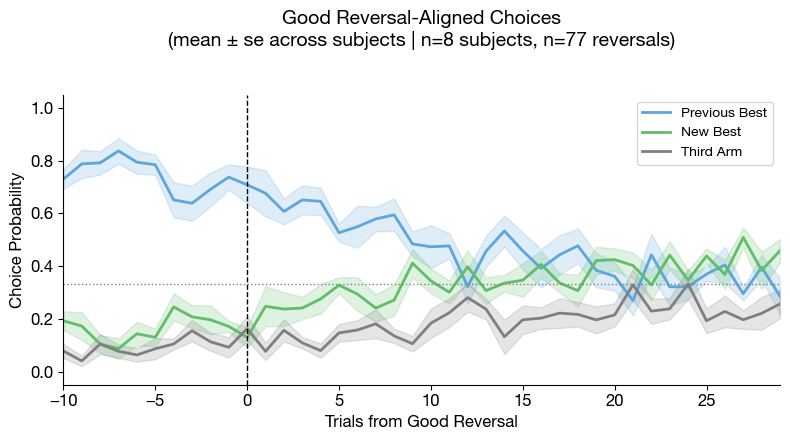

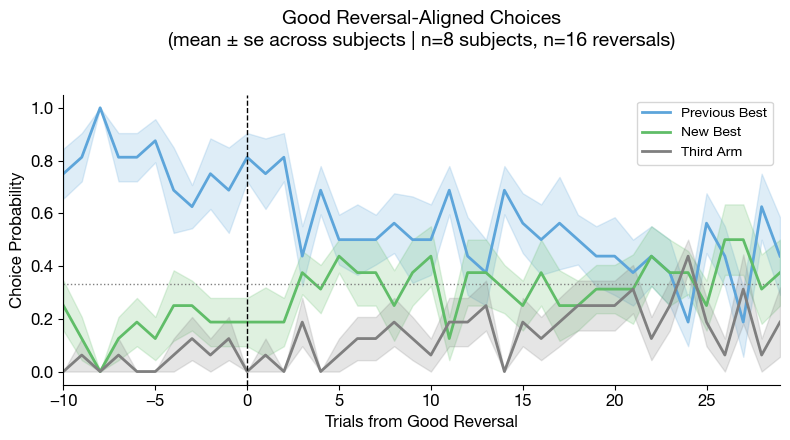

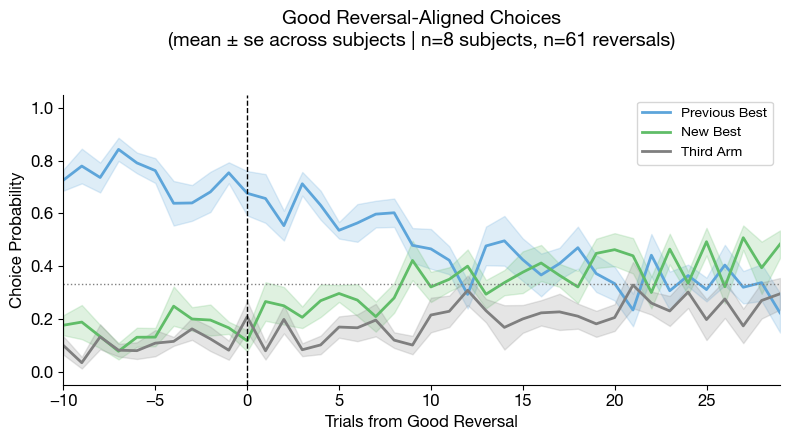

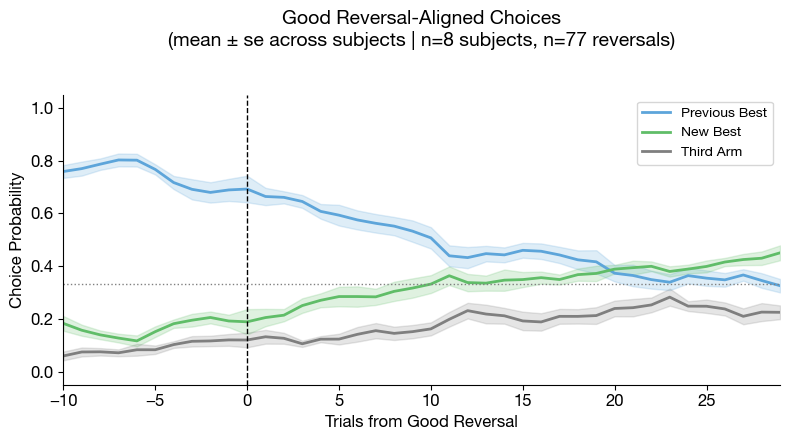

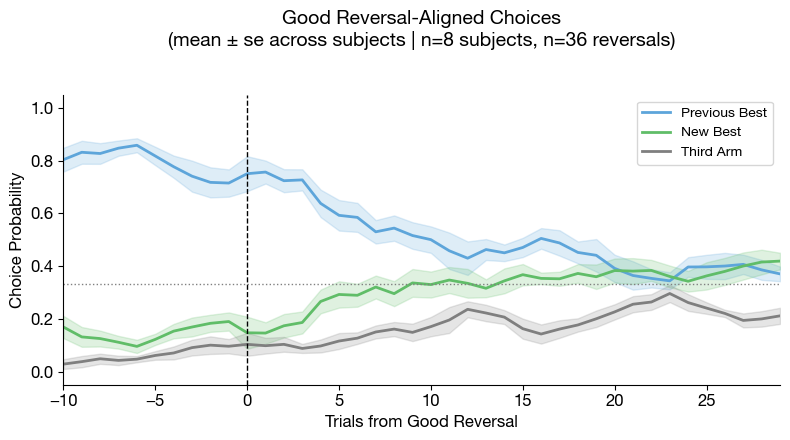

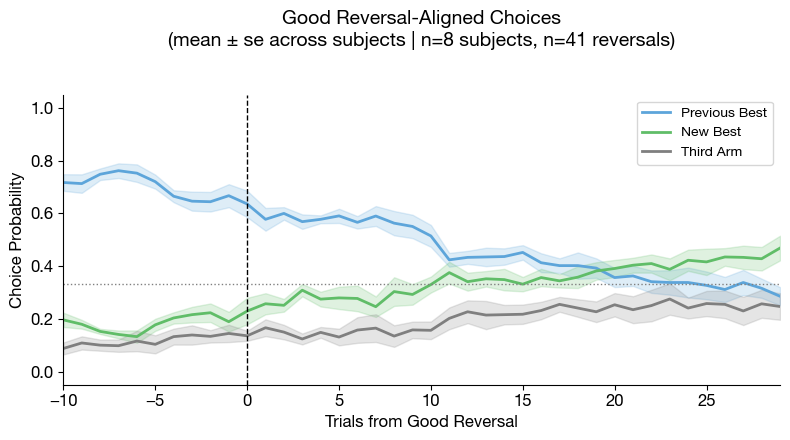

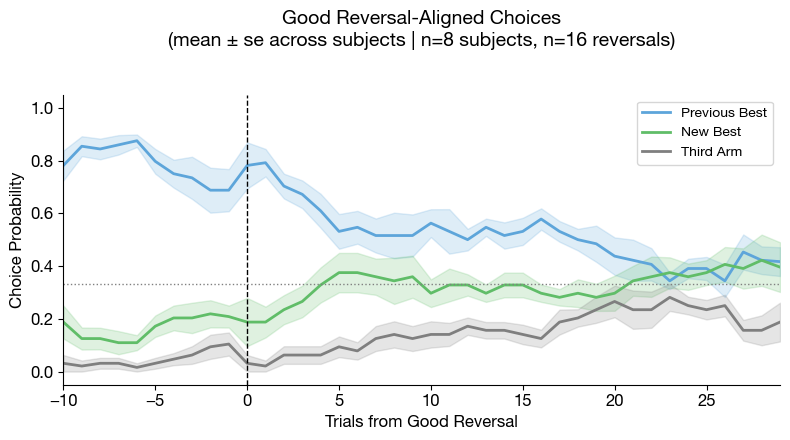

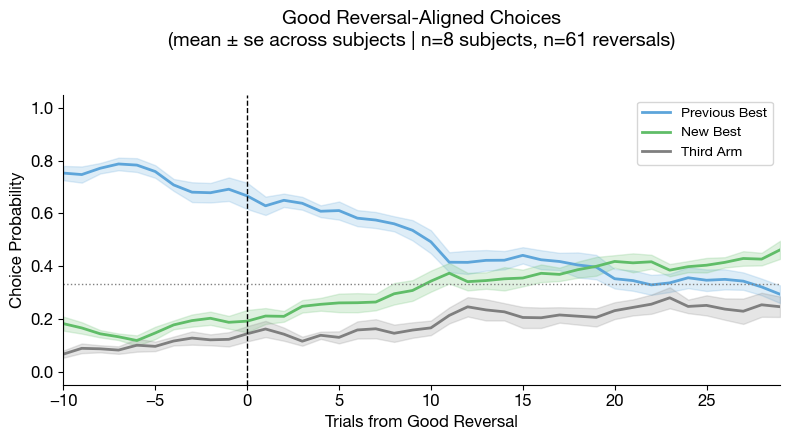

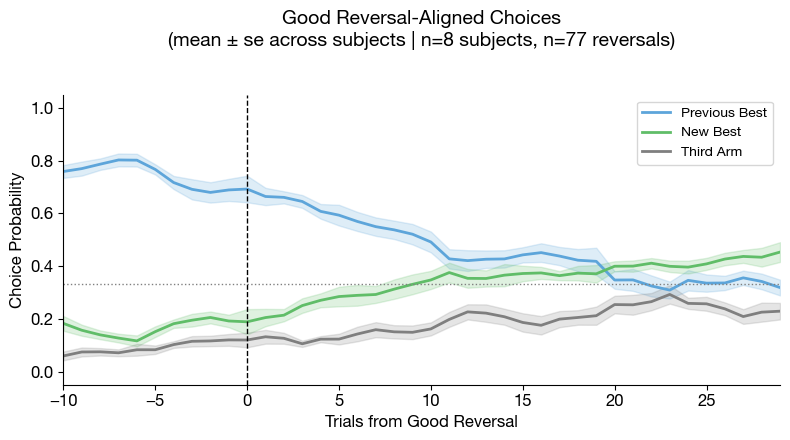

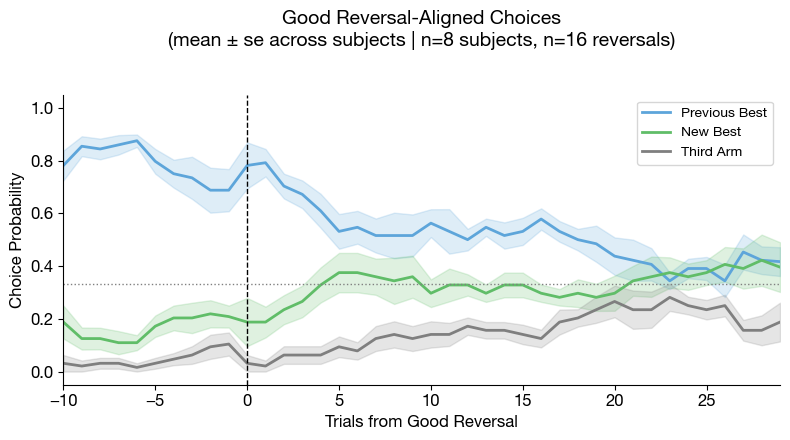

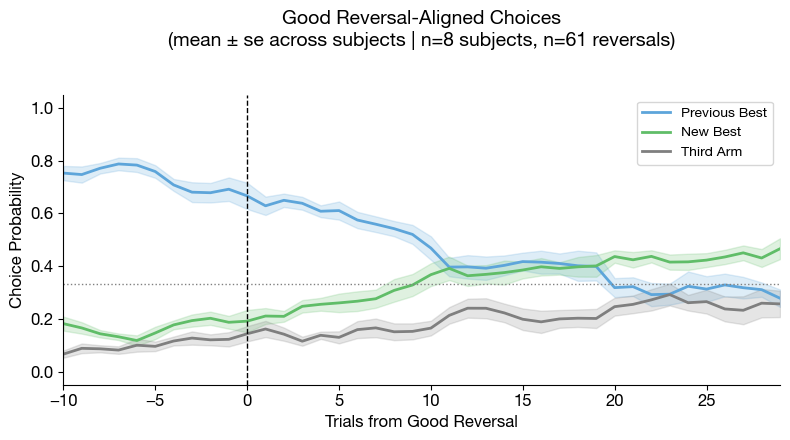

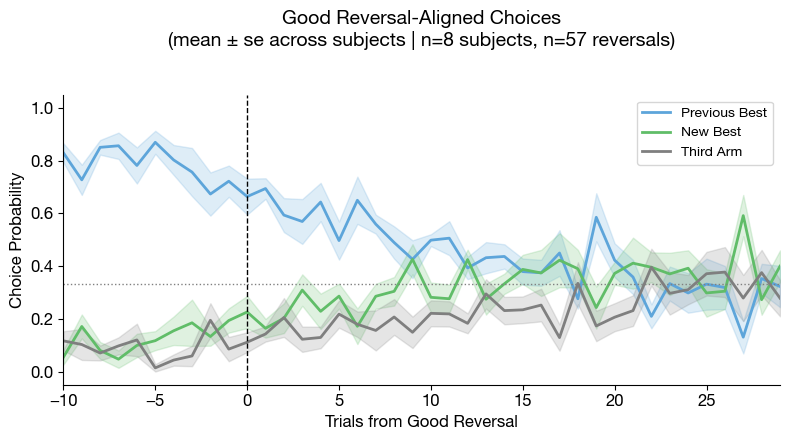

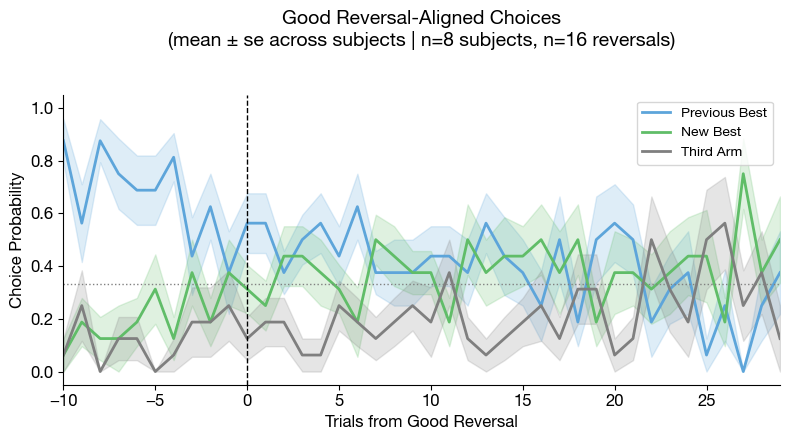

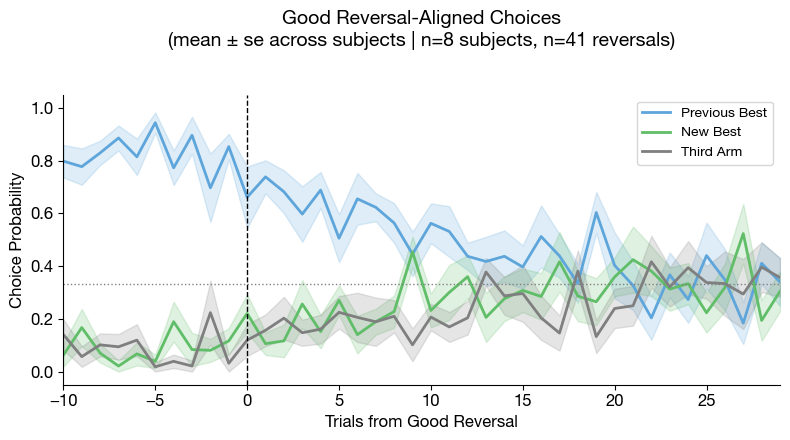

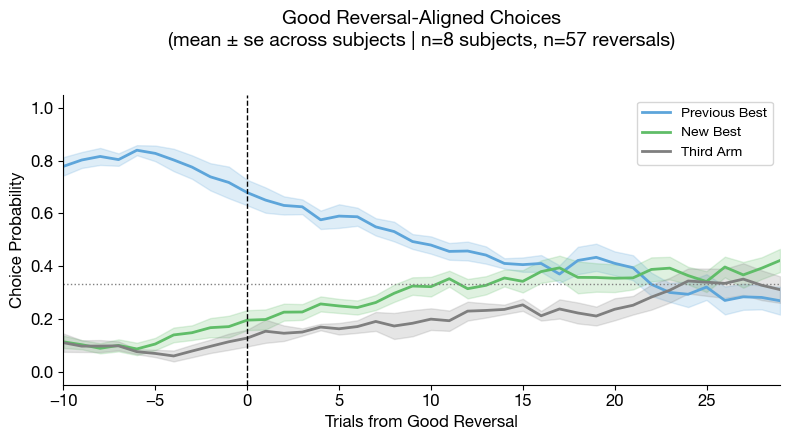

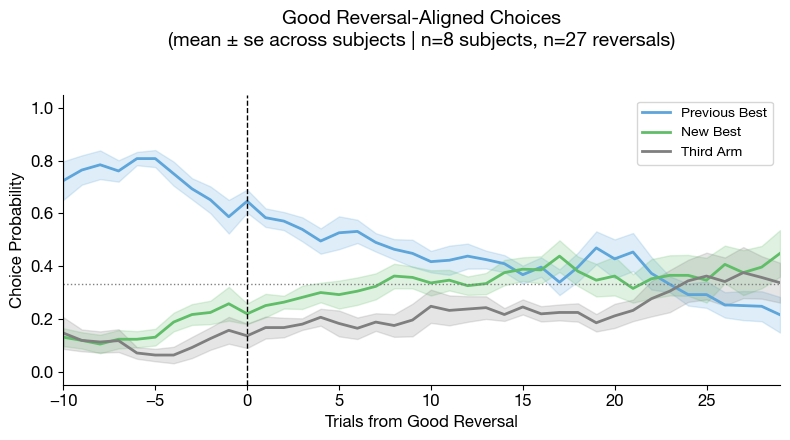

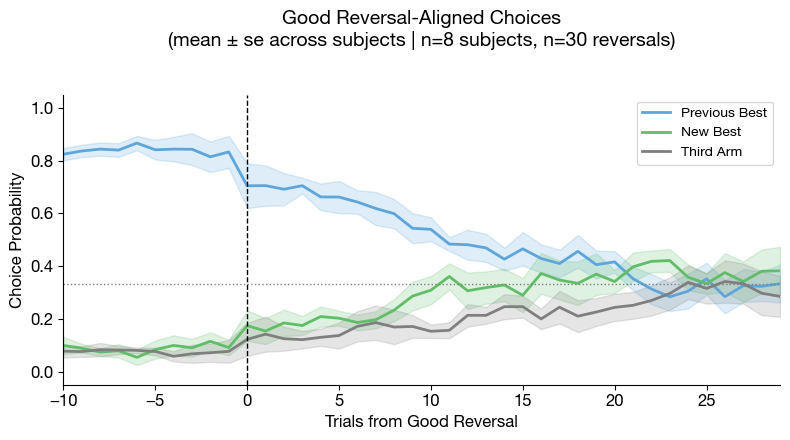

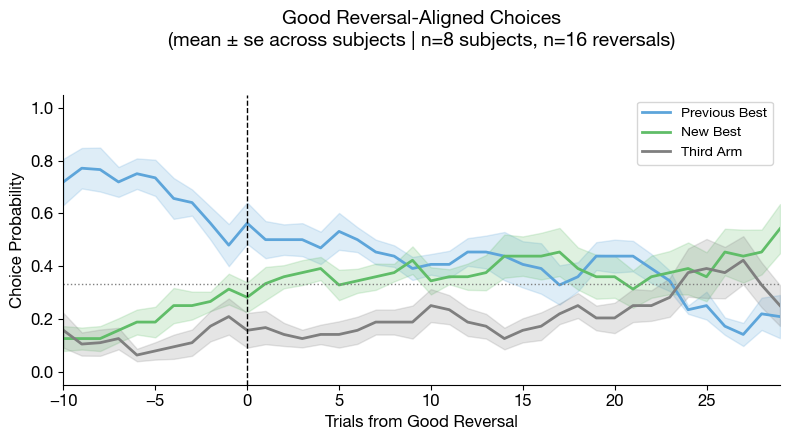

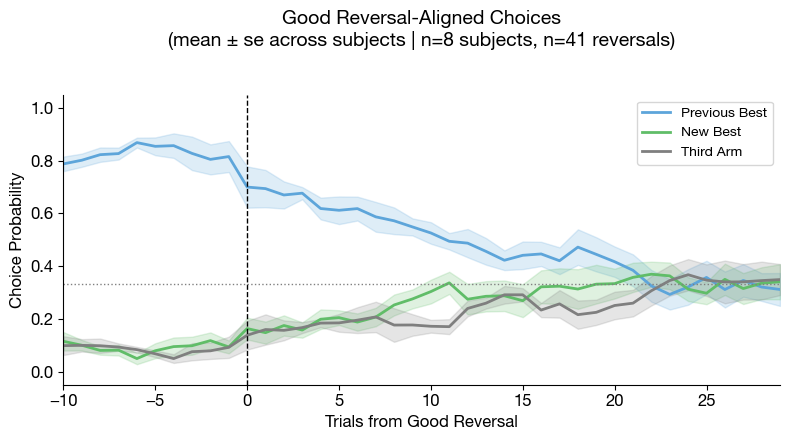

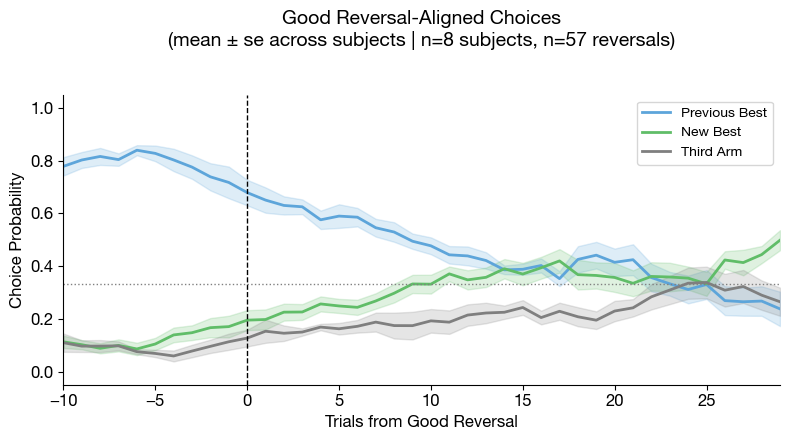

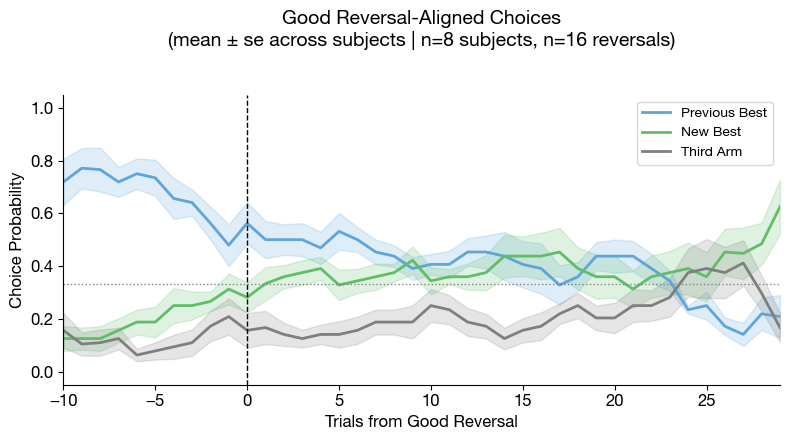

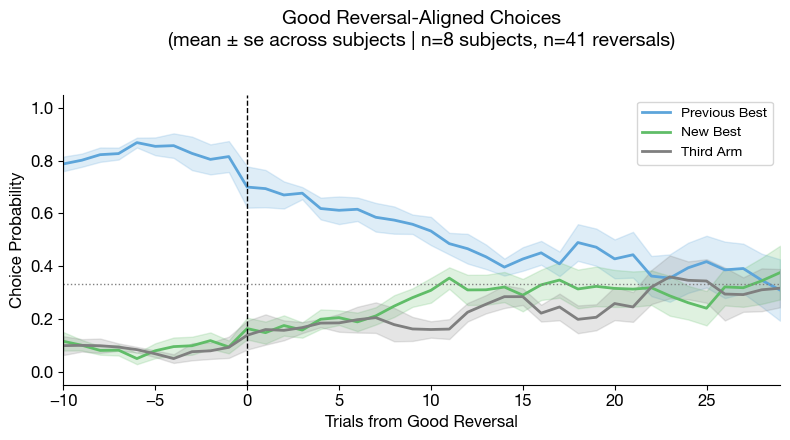

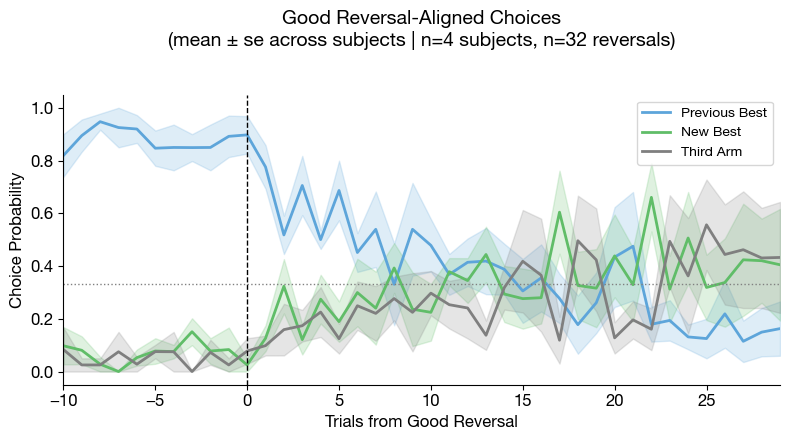

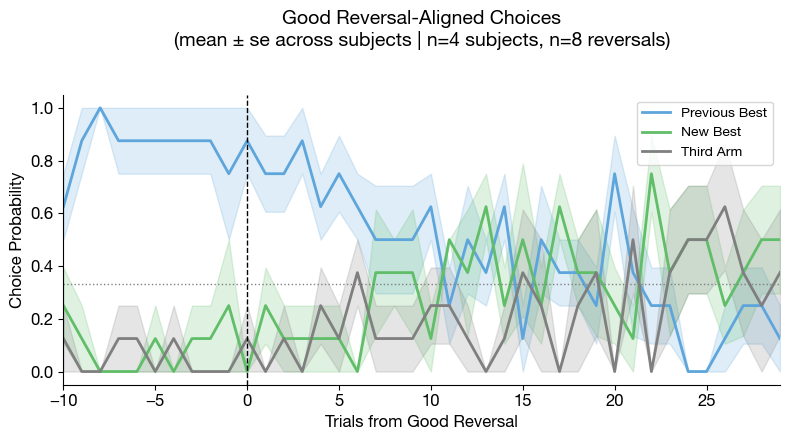

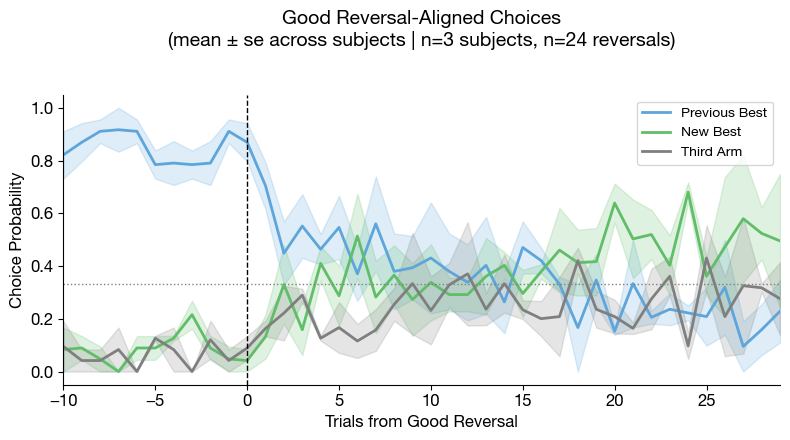

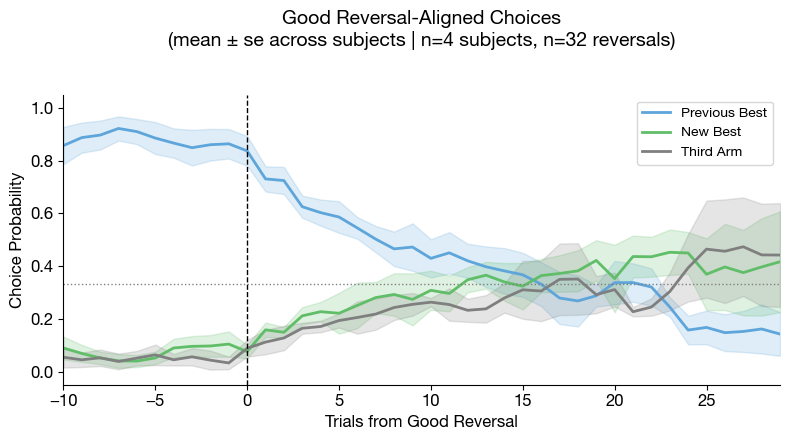

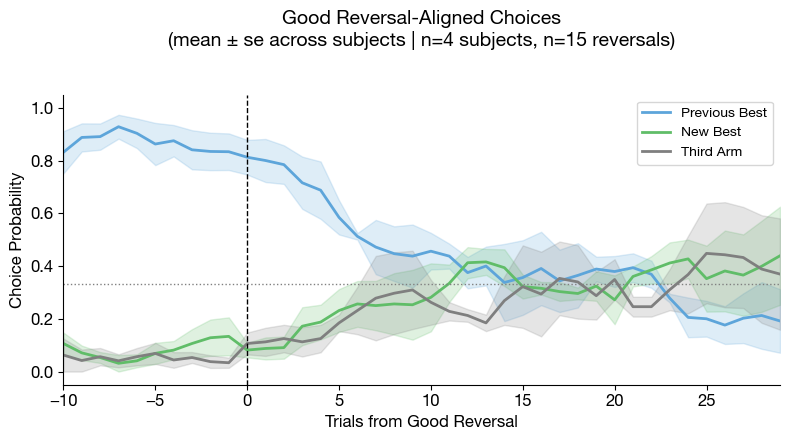

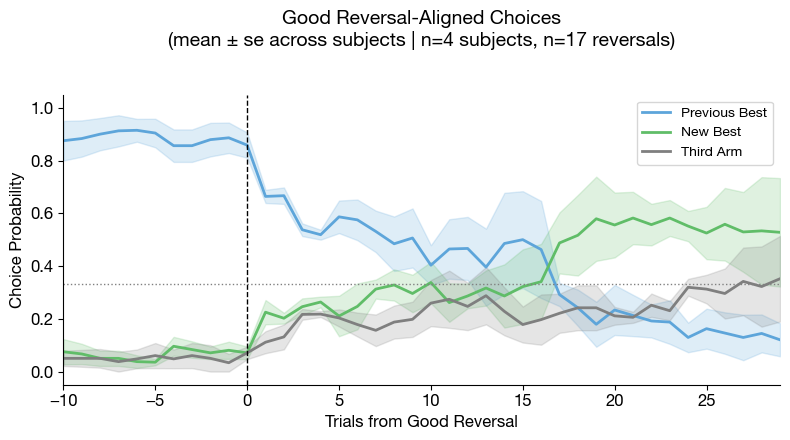

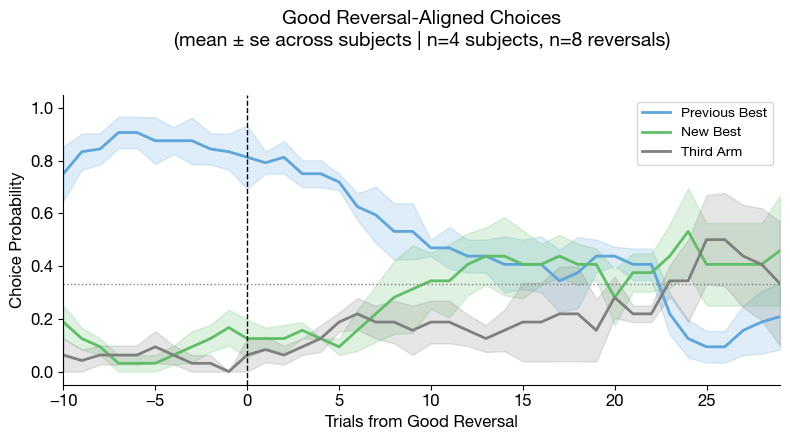

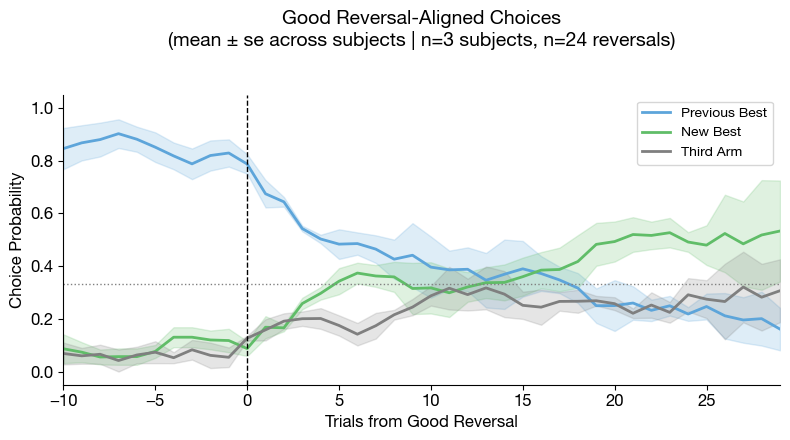

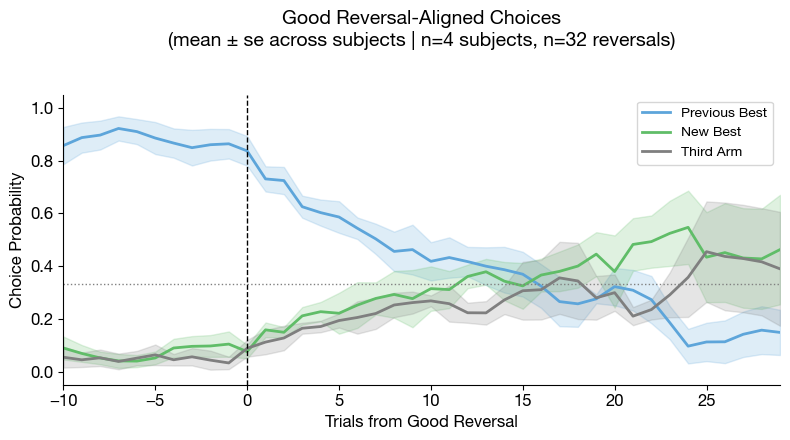

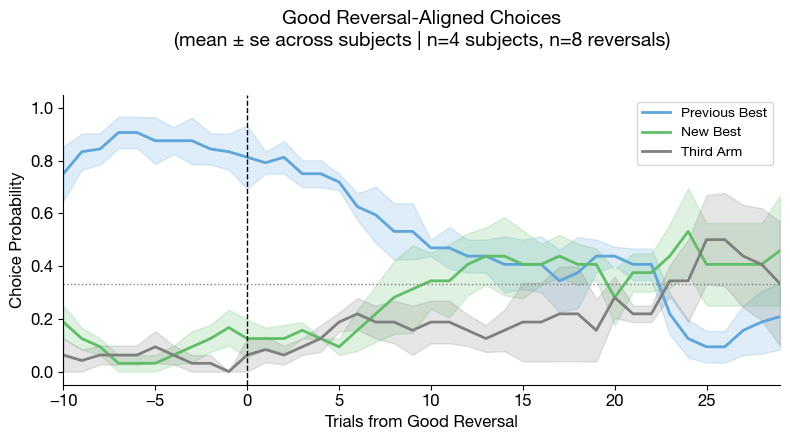

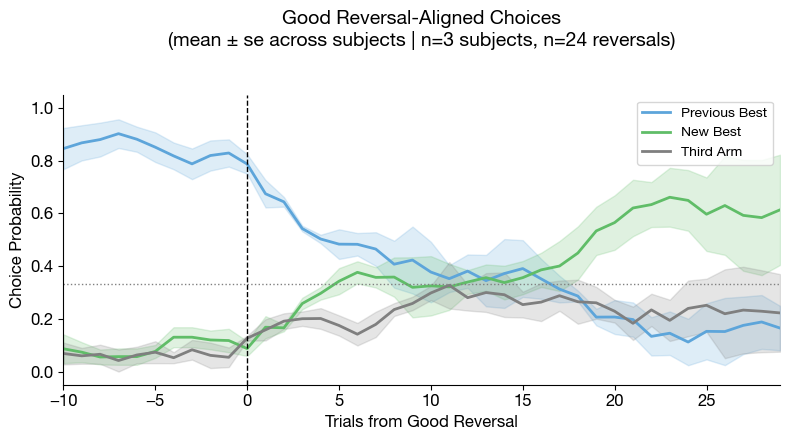

In [74]:
# Reuse the analysis body so this notebook stays in sync with the open-field pipeline.
pipeline_path = repo_root / "scripts" / "full_pipelines" / "run_open_field_analysis.py"
pipeline_source = pipeline_path.read_text()
imports_source = pipeline_source[:pipeline_source.index('task = "open-field"')]
exec(compile(imports_source, str(pipeline_path), "exec"), globals())
analysis_marker = "# Choice Probability Analysis"
analysis_source = pipeline_source[pipeline_source.index(analysis_marker):]
original_data_setup = (
    'root = f"/Volumes/behrens/meg/{folder_name}/{cohort}/rawdata/"\n'
    'subjects_data = import_data(root)\n'
    'subjects_trials_by_problem = extract_trials_grouped_by_problem(subjects_data)\n'
)
filtered_data_setup = (
    'subjects_trials_by_problem = extract_trials_grouped_by_problem(subjects_data)\n'
    + 'if not subjects_trials_by_problem:\n'
    + '    raise ValueError("No available problems found.")\n'
    + 'if problem_numbers is not None:\n'
    + '    requested_problem_numbers = set(problem_numbers)\n'
    + '    missing_problem_numbers = requested_problem_numbers - set(subjects_trials_by_problem)\n'
    + '    if missing_problem_numbers:\n'
    + '        raise ValueError(f"Requested problem number(s) not found: {sorted(missing_problem_numbers)}")\n'
    + '    subjects_trials_by_problem = {number: trials for number, trials in subjects_trials_by_problem.items() if number in requested_problem_numbers}\n'
    + 'print(f"[INFO] Analyzing problem number(s): {sorted(subjects_trials_by_problem)}")\n'
)
if original_data_setup not in analysis_source:
    raise RuntimeError("The open-field pipeline data setup has changed.")
exec(compile(filtered_data_setup, "<problem-selection>", "exec"), globals())
analysis_source = analysis_source.replace(original_data_setup, "", 1)

choice_toggle_replacements = {
    "run_all = True": "run_all = choice_run_all",
    "skip = True": "skip = choice_skip_initial_trials",
    "moving_avg = True": "moving_avg = choice_moving_average",
    "remove_bad = True": "remove_bad = choice_remove_bad",
    "split_by_best_change = False": "split_by_best_change = choice_split_by_best_change",
    "split_by_best_change_and_half = False": "split_by_best_change_and_half = choice_split_by_best_change_and_half",
    "split_by_first_two = True": "split_by_first_two = choice_split_by_first_two",
    "split_by_half = True": "split_by_half = choice_split_by_half",
}
for pipeline_setting, notebook_setting in choice_toggle_replacements.items():
    if pipeline_setting not in analysis_source:
        raise RuntimeError(f"The open-field pipeline setting has changed: {pipeline_setting}")
    analysis_source = analysis_source.replace(pipeline_setting, notebook_setting, 1)

# Reload plot entry points for kernels opened before trial companions were added.
reversal_plot_module = importlib.reload(importlib.import_module("src.behavior_visualization.plot_num_reversals"))
plot_num_reversals_over_time = reversal_plot_module.plot_num_reversals_over_time
plot_moving_avg_reversals_over_time = reversal_plot_module.plot_moving_avg_reversals_over_time
analysis_source = analysis_source.replace(
    "plot_moving_avg_reversals_over_time(subjects_trials, save_path=curr_save_path)",
    "plot_moving_avg_reversals_over_time(subjects_trials, trial_window=reversal_trial_window, save_path=curr_save_path)",
)

rank_analysis_source = """
# Rank Proportion Analysis

# Refresh this module when rerunning in a kernel opened before the helper was added.
import importlib
rank_counts_module = importlib.reload(importlib.import_module(
    "src.behavior_analysis.get_rank_counts_by_good_reversal"))
get_rank_counts_by_value = rank_counts_module.get_rank_counts_by_value

for problem_number, subjects_trials in subjects_trials_by_problem.items():
    problem = f"problem-{problem_number:02d}"
    reversal_windows = get_good_reversal_info(subjects_trials, include_first_block=True)
    rank_results_by_problem[problem_number] = {}
    for value_basis in rank_value_bases:
        label = {"true": "True Value", "believed": "Believed Value"}[value_basis]
        print(f"Running rank proportions: {problem}, {label}")
        rank_counts = get_rank_counts_by_value(subjects_trials, reversal_windows, value_basis=value_basis)
        rank_results_by_problem[problem_number][value_basis] = {}
        for pool_trials in rank_pooling_modes:
            print(f"  pool_trials_within_subject={pool_trials}")
            p_values = pvalue_paired_t_best_vs_second_vs_third(
                rank_counts, pool_trials_within_subject=pool_trials)
            rank_results_by_problem[problem_number][value_basis][pool_trials] = {
                "counts": rank_counts, "p_values": p_values}
            suffix = f" ({label}) (Pool Trials {pool_trials})"
            save_path = f"../../results/figures/{task}/{cohort}/{problem}/choice-stats/Rank Proportions{suffix}"
            plot_rank_proportions(rank_counts, average_across_mice_pvalues=p_values,
                                 pool_trials_within_subject=pool_trials,
                                 save_path=save_path)

"""
rank_start = analysis_source.index("# Rank Proportion Analysis")
rank_end = analysis_source.index("# Single Session Analysis", rank_start)
analysis_source = analysis_source[:rank_start] + rank_analysis_source + analysis_source[rank_end:]

def toggle_section(source, marker, next_marker, enabled, label):
    if enabled:
        return source
    start = source.index(marker)
    end = source.index(next_marker, start) if next_marker else len(source)
    replacement = f'{marker}\n\nprint("[INFO] Skipping {label}.")\n\n'
    return source[:start] + replacement + source[end:]

analysis_sections = [
    ("# Choice Probability Analysis", "# First Leave Analysis", "run_choice_probability_analysis", "choice probability analysis"),
    ("# First Leave Analysis", "# Number of Reversals Analysis", "run_first_leave_analysis", "first leave analysis"),
    ("# Number of Reversals Analysis", "# Rank Proportion Analysis", "run_number_of_reversals_analysis", "number of reversals analysis"),
    ("# Rank Proportion Analysis", "# Single Session Analysis", "run_rank_proportion_analysis", "rank proportion analysis"),
    ("# Single Session Analysis", None, "run_single_session_analysis", "single session analysis"),
]
output_root = repo_root / "results" / "figures"
analysis_template = analysis_source.replace("../../results/figures", str(output_root))
rank_results_by_problem = {}
for selected_problem, selected_trials in sorted(subjects_trials_by_problem.items()):
    settings = original_analysis_settings if selected_problem < 4 else later_analysis_settings
    problem_analysis_source = analysis_template
    for marker, next_marker, setting, label in reversed(analysis_sections):
        problem_analysis_source = toggle_section(
            problem_analysis_source, marker, next_marker, settings[setting], label)
    # Isolate pipeline globals so its loops cannot change the selected problems.
    problem_namespace = dict(globals())
    problem_namespace.update(settings)
    problem_namespace["subjects_trials_by_problem"] = {selected_problem: selected_trials}
    print(f"[INFO] Problem {selected_problem}: using {'original' if selected_problem < 4 else 'revised'} analyses")
    print(f"[INFO] Saving analysis files under {output_root / task / cohort}")
    exec(compile(problem_analysis_source, f"<cohort-03-problem-{selected_problem}>", "exec"), problem_namespace)


## Trial and block-length summaries
Run after the setup and data-loading cells; this section is independent of the reversal-analysis cell. `summary_problem_numbers = None` includes every available problem. Distributions include all observed sessions/blocks. Blocks continue across sessions; potentially incomplete edge blocks are flagged in the exported table. Time plots use calendar dates (daily means when a mouse has multiple observations); problem averages give each mouse equal weight.


In [ ]:
summary_problem_numbers = None  # All problems, or a set such as {1, 2, 3, 4}.
show_trial_block_summary_plots = True

import importlib
summary_analysis = importlib.reload(importlib.import_module("src.behavior_analysis.trial_block_summary"))
summary_plotting = importlib.reload(importlib.import_module("src.behavior_visualization.plot_trial_block_summary"))
from src.behavior_import.extract_trials import extract_trials_grouped_by_problem

summary_problems = extract_trials_grouped_by_problem(subjects_data)
if summary_problem_numbers is not None:
    missing = set(summary_problem_numbers) - set(summary_problems)
    if missing:
        raise ValueError(f"Requested summary problems not found: {sorted(missing)}")
    summary_problems = {p: d for p, d in summary_problems.items() if p in summary_problem_numbers}
if not summary_problems:
    raise ValueError("Select at least one available problem for the summaries.")
subject_numbers = summary_analysis.subject_numbers_from_paths(path for path, _ in eligible_tsv_files)
session_trial_table, block_trial_table = summary_analysis.build_trial_block_tables(summary_problems, subject_numbers)
selection_label = "all-problems" if summary_problem_numbers is None else "problems-" + "-".join(map(str, sorted(summary_problem_numbers)))
summary_save_dir = repo_root / "results" / "figures" / task / cohort / "trial-block-summaries" / selection_label
summary_plot_paths = summary_plotting.plot_trial_block_summaries(
    session_trial_table, block_trial_table, summary_save_dir,
    show=show_trial_block_summary_plots)
print(f"Saved six summary figures (PNG/PDF) and source tables to {summary_save_dir}")


## Problem 2: matched trial budget
Uses each mouse’s first X problem-2 trials, where X is the mean **total problem-2 trial count** for sub-05–08, rounded down. Mice below X retain all available trials and are flagged. Runs the original true-value rank analysis with pooling enabled and its existing block-quality filters, plus total reversals through the cutoff (including confirmed reversals triggered by the final retained trial). Saved separately from the full-data results. Run after setup and data loading.


In [ ]:
# Independent of problem_numbers: this comparison always uses problem 2.
import importlib
import json
import pandas as pd
from src.behavior_import.extract_trials import extract_trials_grouped_by_problem
from src.behavior_analysis.trial_block_summary import subject_numbers_from_paths
from src.behavior_analysis.get_good_reversal_info import get_good_reversal_info
from src.behavior_analysis.get_rank_counts_by_good_reversal import get_rank_counts_by_good_reversal
from src.behavior_analysis.get_diagnostic_p_value import pvalue_paired_t_best_vs_second_vs_third
from src.behavior_analysis.get_total_reversals import get_total_reversals
from src.behavior_visualization.plot_rank_proportions import plot_rank_proportions
from src.behavior_visualization.plot_num_reversals import plot_num_reversals
budget_module = importlib.reload(importlib.import_module("src.behavior_analysis.matched_trial_budget"))

budget_problems = extract_trials_grouped_by_problem(subjects_data)
if 2 not in budget_problems:
    raise ValueError("Problem 2 is not available.")
budget_subject_numbers = subject_numbers_from_paths(path for path, _ in eligible_tsv_files)
problem2_matched_trials, problem2_budget_report = budget_module.match_trial_budget(
    budget_problems[2], budget_subject_numbers)
X = problem2_budget_report["trial_budget"]
print(f"Reference mean total problem-2 trials (sub-05–08): {problem2_budget_report['reference_mean']:.2f}; X = {X} (rounded down)")
display(pd.DataFrame(problem2_budget_report["mice"]))

matched_save_dir = repo_root / "results" / "figures" / task / cohort / "problem-02" / f"first-{X}-trials"
matched_save_dir.mkdir(parents=True, exist_ok=True)
(matched_save_dir / "trial_budget.json").write_text(json.dumps(problem2_budget_report, indent=2) + "\n")
problem2_matched_windows = get_good_reversal_info(problem2_matched_trials, include_first_block=True)
problem2_matched_ranks = get_rank_counts_by_good_reversal(problem2_matched_windows)
problem2_matched_pvalues = pvalue_paired_t_best_vs_second_vs_third(
    problem2_matched_ranks, pool_trials_within_subject=True)
plot_rank_proportions(problem2_matched_ranks,
    average_across_mice_pvalues=problem2_matched_pvalues,
    pool_trials_within_subject=True,
    save_path=str(matched_save_dir / f"Rank Proportions (True Value) (Pool Trials True) (First {X} Trials)"))
plot_num_reversals(problem2_matched_trials,
    save_path=matched_save_dir / f"Total Reversals (First {X} Trials)")
problem2_matched_totals = {mouse: get_total_reversals(sessions) for mouse, sessions in problem2_matched_trials.items()}
pd.DataFrame.from_dict(problem2_matched_totals, orient="index").to_csv(matched_save_dir / "total_reversals.csv", index_label="mouse")
(matched_save_dir / "rank_counts_and_statistics.json").write_text(json.dumps(
    {"counts": problem2_matched_ranks, "p_values": problem2_matched_pvalues}, indent=2, default=str) + "\n")
print(f"Saved problem-2 matched-trial analysis to {matched_save_dir}")
